<a href="https://colab.research.google.com/github/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/blob/main/Entornos_Complejos/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo con Políticas epsilon-soft**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### _________ **Código de la Instalación e Importación**
----

In [3]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [4]:
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7'):
        !git clone https://github.com/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7.git
    %cd /content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/Entornos_Complejos

In [5]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import MonteCarloOnPolicyAgent
from plotting import plot, plot_lengths, plot_scenario

In [6]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

import os
np.random.seed(SEED)
np.random.default_rng(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


In [7]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.


# Fijar la semilla en los entornos (patrón sección 5.4 del PDF)
env4.reset(seed=SEED)
env8.reset(seed=SEED)


(0, {'prob': 1})

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

#### **Código de las políticas y algoritmo MC**
----------------

In [8]:
# @title Acciones del entorno FrozenLake
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3

In [9]:
# @title Agente Monte Carlo On-Policy — importado de agents/monte_carlo_on_policy_agent.py
# MonteCarloOnPolicyAgent implementa el Algoritmo 3 de Sutton & Barto (2018):
#   - todas las visitas, retornos hacia atrás, media incremental
#   - política epsilon-greedy heredada de GymnasiumAgent
#   - decay opcional: epsilon = min(1.0, 1000/(t+1))
#   - método train(num_episodes) con bucle episódico estándar (sección 5.2)
#   - método stats() devuelve (list_stats, list_lengths)
#   - atributo q_values: tabla Q aprendida (nS × nA)

## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

   

### **3.1 Repressentaciones Gráficas**
Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.

Además se muestra la gráfica $f(t) = \text{len}(\text{episodio}_t)$, es decir, la longitud de cada episodio junto con su curva de tendencia (media móvil).

Hay que tener en cuenta que en FrozenLake los episodios solo terminan de dos formas:
- **Fracaso** (cae en un agujero H): episodio corto, recompensa 0.
- **Éxito** (alcanza la meta G): episodio de longitud igual al camino recorrido, recompensa 1.

**¿Por qué esta gráfica es entonces un buen indicador de aprendizaje?**

Porque nos permite ver en la curva ciertas tendencias que sigue el agente durante el entrenamiento. Si las vemos observaremos 3 fases características:

1. **Inicio:** el agente actúa casi aleatoriamente. Cae pronto en agujeros por lo que termina con episodios muy cortos o deambula sin rumbo (episodios exesivamente largos de hasta 100 pasos).

2. **Aprendizaje intermedio:** el agente empieza a aprender a evitar agujeros pero aún no conoce el camino óptimo, aun así, mediante la media móvil vemos como se tiende a disminuir la media de los pasos totales dados, aunque aun se esten dando casos de episodios muy cortos o largos.

3. **Convergencia:** los episodios exitosos se estabilizan en la longitud del camino óptimo (~7 pasos en 4×4, ~14 pasos en 8×8) con menor variabilidad. La tendencia decreciente confirma mayor eficiencia, no solo mayor tasa de éxito.

Por tanto mientras que la primera gráfica mide *con qué frecuencia* el agente tiene éxito, la segunda mide *con qué eficiencia* lo consigue. Un agente que ha aprendido bien muestra simultáneamente alta tasa de éxito y longitud estabilizada en el camino óptimo.


In [10]:
# @title Funciones de visualización — importadas de plotting/plotting.py
# plot(list_stats)               → proporción de recompensas por episodio
# plot_lengths(list_lengths)     → longitud de episodios con media móvil
# plot_scenario(env, Q, title)   → grid FrozenLake con flechas de política óptima

### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




In [11]:
# @title Aprendizaje
agent4 = MonteCarloOnPolicyAgent(env4, epsilon=0.4, discount_factor=1.0)
agent4.train(num_episodes=50000)
list_stats, list_lengths = agent4.stats()
Q = agent4.q_values

 11%|█         | 5410/50000 [00:02<00:12, 3634.72it/s]

success: 0.3920, epsilon: 0.4000


 21%|██▏       | 10683/50000 [00:03<00:10, 3784.71it/s]

success: 0.4595, epsilon: 0.4000


 31%|███       | 15593/50000 [00:04<00:09, 3728.01it/s]

...

success: 0.5132, epsilon: 0.4000


 92%|█████████▏| 45750/50000 [00:13<00:01, 3776.55it/s]

success: 0.5155, epsilon: 0.4000


100%|██████████| 50000/50000 [00:14<00:00, 3511.30it/s]

success: 0.5171, epsilon: 0.4000


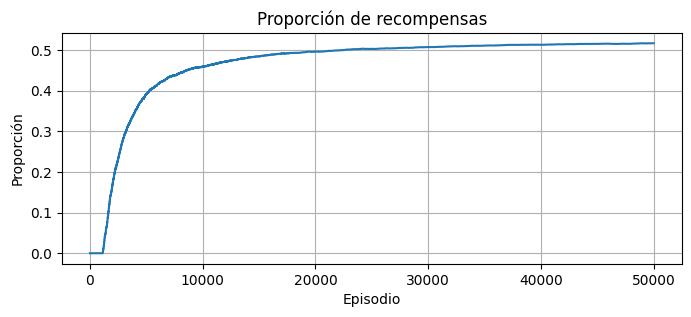

Máxima proporcion: 0.51708


In [12]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

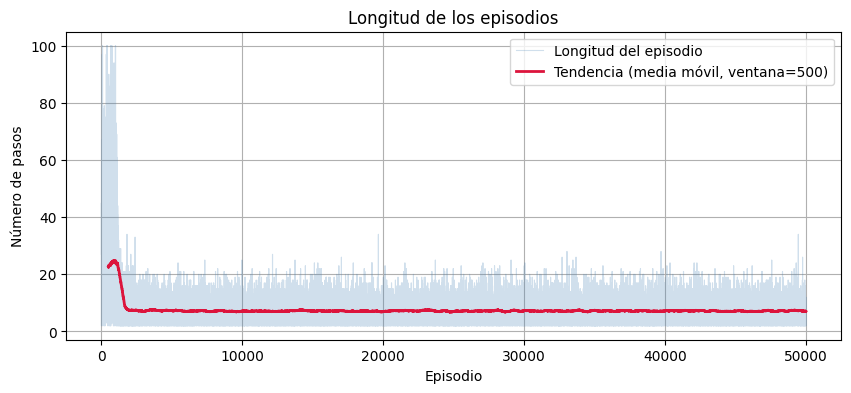

Longitud media final (últimos 1000 episodios): 7.15 pasos


In [13]:
#@title Longitud de episodios por número de episodio (4x4)

plot_lengths(list_lengths)
print(f"Longitud media final (últimos 1000 episodios): {np.mean(list_lengths[-1000:]):.2f} pasos")

####.
 Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [14]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)


Valores Q para cada estado:
 [[0.2050065  0.44935839 0.50846216 0.43751488]
 [0.42341878 0.         0.59979636 0.47805643]
 [0.50709588 0.62455826 0.51349481 0.59604568]
 [0.59017697 0.         0.50253807 0.46722846]
 [0.09514087 0.56322175 0.         0.31451613]
 [0.         0.         0.         0.        ]
 [0.         0.80652673 0.         0.60178571]
 [0.         0.         0.         0.        ]
 [0.18919873 0.         0.6888361  0.36206897]
 [0.48870968 0.8246516  0.77286136 0.        ]
 [0.71137189 0.95835706 0.         0.6295977 ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.82704918 0.95725102 0.72094926]
 [0.81586095 0.95923988 1.         0.80406705]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tiene 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

- A continuación se visualiza el escenario 4×4 con las flechas de la política óptima superpuestas: cada celda libre (F) y la celda de salida (S) muestran la dirección que maximiza Q(s,·), mientras que los agujeros (H) y la meta (G) se identifican con su etiqueta y color característico.

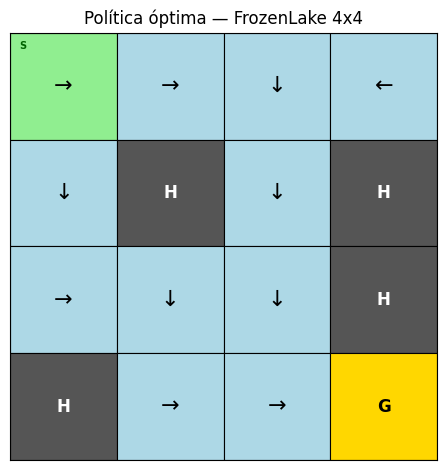

In [15]:
#@title Escenario con política óptima (4x4)
plot_scenario(env4, Q, title="Política óptima — FrozenLake 4x4")

In [16]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = agent4.pi_star()

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2, 2, 1, 1, 1, 2 
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG




In [17]:
# @title Aprendizaje
agent8 = MonteCarloOnPolicyAgent(env8, epsilon=0.4, decay=True, discount_factor=1.0)
agent8.train(num_episodes=50000)
list_stats, list_lengths = agent8.stats()
Q = agent8.q_values

 10%|█         | 5147/50000 [00:04<00:33, 1354.24it/s]

success: 0.4866, epsilon: 0.2000


 21%|██        | 10323/50000 [00:08<00:24, 1650.72it/s]

success: 0.6904, epsilon: 0.1000


 30%|███       | 15186/50000 [00:10<00:20, 1730.03it/s]

...

success: 0.9016, epsilon: 0.0250


 91%|█████████ | 45270/50000 [00:27<00:02, 1839.41it/s]

success: 0.9108, epsilon: 0.0222


100%|██████████| 50000/50000 [00:30<00:00, 1638.20it/s]

success: 0.9180, epsilon: 0.0200


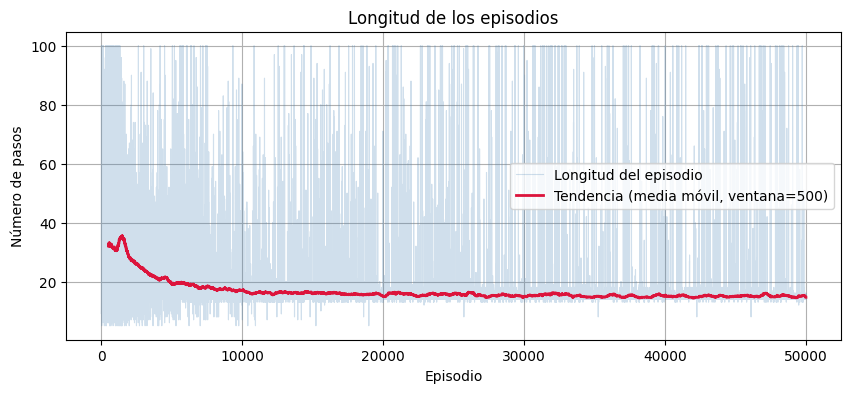

Longitud media final (últimos 1000 episodios): 14.87 pasos


In [18]:
#@title Longitud de episodios por número de episodio (8x8)

plot_lengths(list_lengths)
print(f"Longitud media final (últimos 1000 episodios): {np.mean(list_lengths[-1000:]):.2f} pasos")

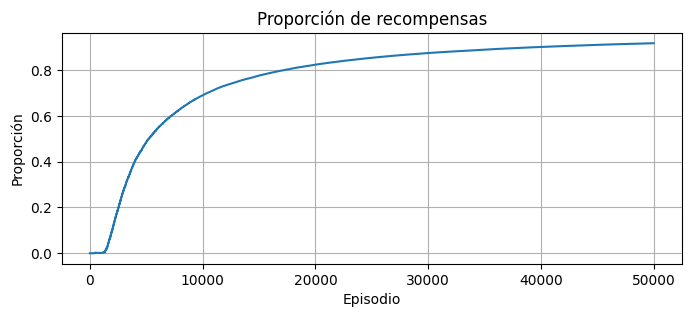

Máxima proporcion: 0.918


In [19]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

####.
Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [20]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)

Valores Q para cada estado:
 [[0.31478135 0.27633478 0.91052202 0.32360183]
 [0.39760192 0.33877551 0.92645205 0.4212963 ]
 [0.47976879 0.47219132 0.93568245 0.52645936]
 [0.57597877 0.5784044  0.94347906 0.60293091]
 [0.62189441 0.94863179 0.66666667 0.67194005]
 [0.27058824 0.77021068 0.25663717 0.27102804]
 [0.21789883 0.72893773 0.20647773 0.21266968]
 [0.22608696 0.71219065 0.24271845 0.24242424]
 [0.54193268 0.29749277 0.29493308 0.41371269]
 [0.44088919 0.0781797  0.08529742 0.12868048]
 [0.09866221 0.07560137 0.07305195 0.62289264]
 [0.19230769 0.         0.71428571 0.21038961]
 [0.63963211 0.65282686 0.95189943 0.67482517]
 [0.70491803 0.69481091 0.9545675  0.71241259]
 [0.73548387 0.7367406  0.95615706 0.74319066]
 [0.74791474 0.95652081 0.76465028 0.72372093]
 [0.07072136 0.05774278 0.35655738 0.06590258]
 [0.14035088 0.12342569 0.32705018 0.19864865]
 [0.26791277 0.1381323  0.         0.57883598]
 [0.         0.         0.         0.        ]
 [0.         0.09448819 0.76358

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tiene 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

- A continuación se visualiza el escenario 8×8 con las flechas de la política óptima superpuestas: cada celda libre (F) y la celda de salida (S) muestran la dirección que maximiza Q(s,·), mientras que los agujeros (H) y la meta (G) se identifican con su etiqueta y color característico.

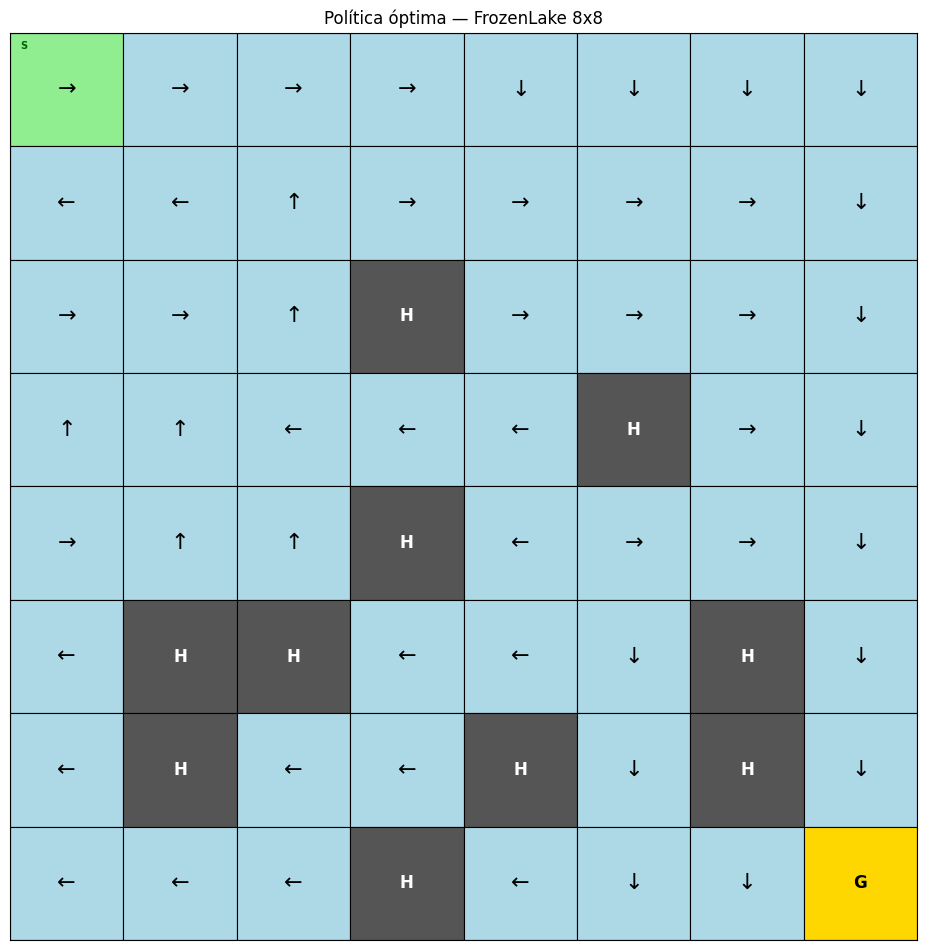

In [21]:
#@title Escenario con política óptima (8x8)
plot_scenario(env8, Q, title="Política óptima — FrozenLake 8x8")

In [22]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = agent8.pi_star()

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())
print()

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2,

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.
